In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt






In [22]:
data=pd.read_csv('ic272_lab4_rent.csv')
data.head()

,area,rooms,age,dist_km,floors,rent
0,6.95,1.0,2.07,3.37,3.0,49.43
1,6.60,1.0,4.16,2.75,3.0,49.77
2,7.94,3.0,1.55,1.50,3.0,67.01
3,8.11,1.0,4.63,8.55,3.0,47.21
4,6.08,2.0,3.04,2.99,1.0,45.25


In [23]:
data.describe()

,area,rooms,age,dist_km,floors,rent
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.266100,3.046667,3.959333,4.987433,1.986667,54.404133
std,1.278202,1.425223,2.199084,2.319815,0.817752,10.645547
min,5.050000,1.000000,0.000000,1.020000,1.000000,29.550000
25%,6.197500,2.000000,2.227500,2.887500,1.000000,47.345000
50%,7.355000,3.000000,3.915000,4.960000,2.000000,54.150000
75%,8.237500,4.000000,5.750000,7.065000,3.000000,61.820000
max,9.500000,5.000000,7.950000,8.910000,3.000000,85.940000


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   area     300 non-null    float64
 1   rooms    300 non-null    float64
 2   age      300 non-null    float64
 3   dist_km  300 non-null    float64
 4   floors   300 non-null    float64
 5   rent     300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB


In [25]:
def train_test_split_scratch(X,y,test_frac,seed):
    np.random.default_rng(seed)
    n=int(len(X)*test_frac)
    idx=np.random.permutation(np.arange(len(X)))
    X_test=X.iloc[idx[:n]]
    y_test=y.iloc[idx[:n]]
    X_train=X.iloc[idx[n:]]
    y_train=y.iloc[idx[n:]]
    return X_train, X_test, y_train, y_test



In [26]:
def fit_simple_lr(x,y):
    x_mean=np.mean(x)
    y_mean=np.mean(y)
    w=np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
    b=y_mean-w*x_mean
    return w,b


In [27]:
w,b=fit_simple_lr(data['area'],data['rent'])
print(f"w: {w:.3f}, b: {b:.3f}")

w: 5.743, b: 12.674


Text(0, 0.5, 'rent')

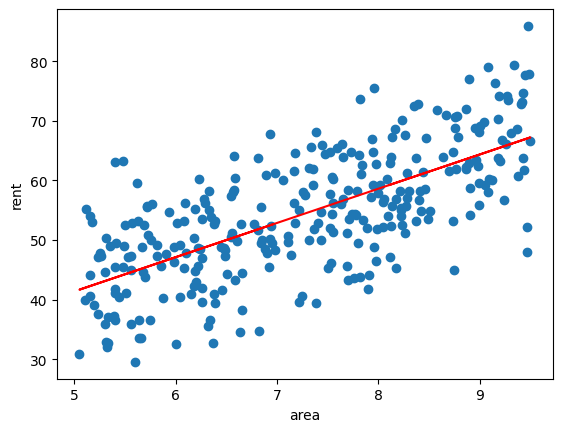

In [28]:
plt.scatter(data['area'],data['rent'],label='data')
plt.plot(data['area'],w*data['area']+b,color='red',label='fit')
plt.xlabel('area')
plt.ylabel('rent')

In [29]:
def design_matrix(X):
    return np.column_stack((np.ones(len(X)),X))
a=design_matrix(data['area'])
np.shape(a)

(300, 2)

In [30]:
def fit_normal_equation(X,y):
    A = design_matrix(X)
    AtA = A.T @ A
    Aty = A.T @ y
    theta = np.linalg.solve(AtA, Aty)
    return theta


In [31]:
X_multi=data[['area', 'rooms', 'age', 'dist_km', 'floors']]
y=data['rent']

X_train,X_test,y_train,y_test=train_test_split_scratch(X_multi,y,0.2,0)

In [32]:
theta_hat_normal= fit_normal_equation(X_train,y_train)
features = ['Intercept', 'area', 'rooms', 'age', 'dist_km', 'floors']
theta_df = pd.DataFrame({'Feature': features, 'Coefficient': np.round(theta_hat_normal, 3)})
print(theta_df.to_string(index=False))

  Feature  Coefficient
Intercept       11.243
     area        6.129
    rooms        3.244
      age       -1.393
  dist_km       -1.866
   floors        1.800


In [35]:
def fit_gradient_descent(X, y, lr, n_iters):
    A = design_matrix(X)
    n = A.shape[0]
    theta = np.zeros(A.shape[1])
    loss_history = []
    
    for _ in range(n_iters):
        # Calculate the error vector
        error = A @ theta - y
        
        # J(theta) = (1/n) * ||error||^2
        loss = (1/n) * np.sum(error**2)
        loss_history.append(loss)
        
        # Gradient = (2/n) * A.T @ error
        gradient = (2/n) * A.T @ error
        
        # Update rule
        theta = theta - lr * gradient
        
    return theta, loss_history

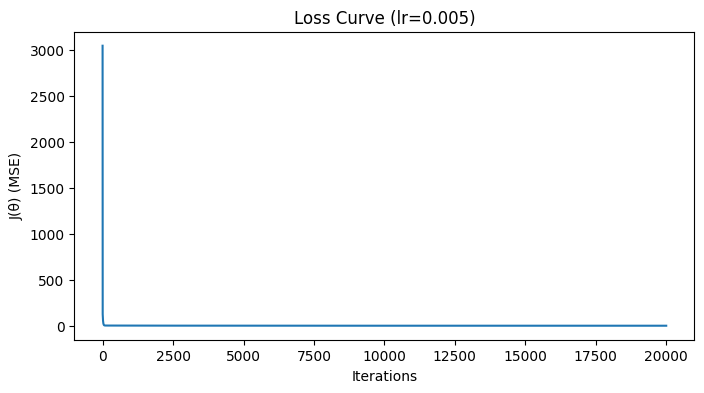

--- Task 3(b): GD vs Normal Equation ---
Largest absolute difference: 0.317751


/home/remandey/.local/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/remandey/.local/lib/python3.10/site-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, a)


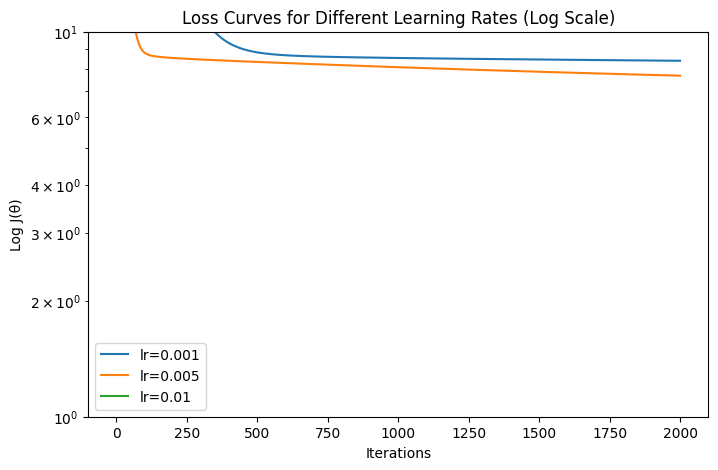

In [36]:
theta_gd, loss_hist = fit_gradient_descent(X_train, y_train, lr=0.005, n_iters=20000)

plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.title('Loss Curve (lr=0.005)')
plt.xlabel('Iterations')
plt.ylabel('J(θ) (MSE)')
plt.show()

max_diff = np.max(np.abs(theta_hat_normal - theta_gd))
print(f"--- Task 3(b): GD vs Normal Equation ---")
print(f"Largest absolute difference: {max_diff:.6f}")

# Task 3(c) Learning Rate Comparison
lrs = [0.001, 0.005, 0.01]
plt.figure(figsize=(8, 5))

for lr in lrs:
    _, loss_h = fit_gradient_descent(X_train, y_train, lr=lr, n_iters=2000)
    plt.plot(loss_h, label=f'lr={lr}')

plt.yscale('log')
plt.title('Loss Curves for Different Learning Rates (Log Scale)')
plt.xlabel('Iterations')
plt.ylabel('Log J(θ)')
plt.legend()
plt.show()

--- Task 4(a): Evaluation ---
Test RMSE: 2.4270
Test R2:   0.9488
Train R2:  0.9399


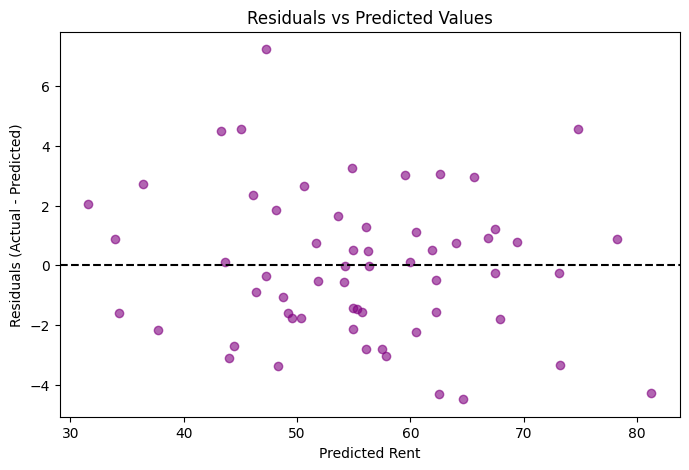

In [40]:
# Task 4(a) Metrics
def rmse(y_true, y_pred):
    n = len(y_true)
    return np.sqrt((1/n) * np.sum((y_true - y_pred)**2))

def r2_score_scratch(y_true, y_pred):
    y_mean = np.mean(y_true)
    # Ratio of unexplained variance to total variance
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)
    return 1 - (ss_res / ss_tot)

A_test = design_matrix(X_test)
y_pred_test = A_test @ theta_gd

A_train = design_matrix(X_train)
y_pred_train = A_train @ theta_gd

print("--- Task 4(a): Evaluation ---")
print(f"Test RMSE: {rmse(y_test, y_pred_test):.4f}")
print(f"Test R2:   {r2_score_scratch(y_test, y_pred_test):.4f}")
print(f"Train R2:  {r2_score_scratch(y_train, y_pred_train):.4f}")

# Task 4(b) Residuals
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()